<h1 style="font-family: 'Georgia', 'Times New Roman', serif; font-size:28px;">Industry Rotation Project</h1>


---

## Executive Summary

This project investigates whether predictive signals derived from momentum, volatility, and macroeconomic variables can generate economically meaningful industry rotation strategies in the U.S. equity market. Using monthly U.S. industry portfolios from the Ken French Data Library and macroeconomic data from FRED, we evaluate linear and nonlinear predictive models within a strict out-of-sample framework.

We implement rolling and expanding window forecasts using OLS, Ridge regression, and Random Forest models, with the historical mean serving as the benchmark. While statistical predictability, measured by out-of-sample \( R^2 \), is generally weak—particularly for OLS—regularisation substantially improves forecast stability, and nonlinear methods capture limited additional structure.

Despite poor statistical performance, long–short industry rotation strategies constructed from forecast rankings deliver economically significant results. In particular, the Ridge-based strategy achieves strong cumulative performance and a Sharpe ratio exceeding 2.0, clearly outperforming both OLS and Random Forest strategies as well as an equal-weighted industry benchmark.

Overall, the findings highlight a critical distinction between statistical and economic predictability in asset returns. Even noisy forecasts can generate value when appropriately translated into portfolio decisions, underscoring the importance of model regularisation and economically aligned evaluation criteria in practical asset allocation.


## Section 1: Project Background and Research Question

Return predictability is a central yet controversial topic in empirical asset pricing. While a large body of literature documents that financial returns are difficult to forecast at the aggregate market level, there is evidence that **cross-sectional differences**, such as those across industries, may exhibit more stable relationships with economic fundamentals.

Industry portfolios provide a natural testing ground for predictive modelling. Compared to individual stocks, industry-level returns aggregate firm-specific noise and are more closely linked to macroeconomic conditions, business cycles, and sector-specific dynamics. As a result, they are particularly relevant for studying **sector rotation strategies**, which aim to reallocate capital across industries based on changing economic environments.

Recent advances in data availability and machine learning methods have renewed interest in whether predictive signals—such as momentum, volatility, and macroeconomic variables—can be systematically exploited for investment purposes. However, improved statistical fit does not necessarily translate into economic value, especially in the presence of estimation error and overfitting.

This project addresses the following research question:

> **Can predictive models based on momentum, volatility, and macroeconomic variables generate economically meaningful out-of-sample industry rotation strategies in the U.S. equity market?**

To answer this question, we evaluate both statistical forecasting performance and economic outcomes under a strict out-of-sample framework, placing particular emphasis on the distinction between **statistical predictability** and **economic value**.

---

## Section 2: Library Imports and Global Settings

This section imports all required Python libraries and defines global settings used throughout the notebook. The analysis relies on standard data science and econometric packages for data handling, model estimation, and evaluation.

To ensure reproducibility and consistency, we adopt a unified set of libraries across all sections. The focus is on transparency and clarity rather than extensive engineering or modularisation, in line with the requirements of the coursework.

Key components include:
- Data manipulation and numerical computation
- Data retrieval from external sources (Ken French Data Library and FRED)
- Linear and nonlinear predictive models
- Evaluation metrics for statistical and economic performance
- Visualisation tools for result interpretation

All subsequent sections build on these global settings.


## Section 3 — Data acquisition

This section downloads industry returns, the risk-free rate, and selected macroeconomic series from the Ken French Data Library and FRED. Code cells below perform data retrieval and initial conversions to monthly series.


In [136]:
import pandas as pd
import numpy as np
import random

from pandas_datareader import data as pdr
import matplotlib.pyplot as plt

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

In [137]:
# Download Fama-French 49 Industry Portfolios (monthly returns)
ff_industry = pdr.DataReader(
    "49_Industry_Portfolios",
    "famafrench"
)

# Extract value-weighted monthly returns
industry_returns = ff_industry[1].copy()

# Convert percentage returns to decimal
industry_returns = industry_returns / 100

# Convert PeriodIndex to DatetimeIndex (end of month)
industry_returns.index = industry_returns.index.to_timestamp()

industry_returns.head()

/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71837/3962752874.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_industry = pdr.DataReader(
/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71837/3962752874.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_industry = pdr.DataReader(
/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71837/3962752874.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_industry = pdr.DataReader(
/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-01,0.0265,0.0392,-0.0207,0.0558,0.0536,0.0066,0.1658,0.1417,0.0768,0.1256,...,0.0228,0.1705,0.1424,0.0273,0.1069,0.1209,0.0948,0.1408,0.0761,0.1027
2021-03-01,0.0536,0.0272,0.0289,0.0575,0.1086,-0.0024,0.0065,0.0740,0.0555,0.0431,...,0.1184,0.0903,0.0780,0.0983,0.0564,0.0796,0.0687,0.0024,0.0430,0.0651
2021-04-01,0.0151,0.0153,-0.0080,0.0812,-0.0201,0.0337,0.0394,0.0301,0.0780,0.0878,...,0.0690,-0.0157,0.0187,0.0284,0.0716,0.0235,0.0442,0.0028,0.0534,0.0164
2021-05-01,-0.0238,0.0414,0.0838,0.0636,-0.0260,0.0433,0.0744,0.0396,0.0181,-0.0134,...,0.0009,0.0105,0.1008,0.0565,-0.0148,0.0385,0.0057,0.0645,0.0480,0.0141
2021-06-01,0.0061,-0.0027,0.0418,-0.0229,0.0326,0.0298,0.0108,0.0199,-0.0008,0.0218,...,-0.0315,-0.0629,-0.0103,0.0346,0.0158,-0.0285,-0.0164,0.0206,0.0263,0.0127


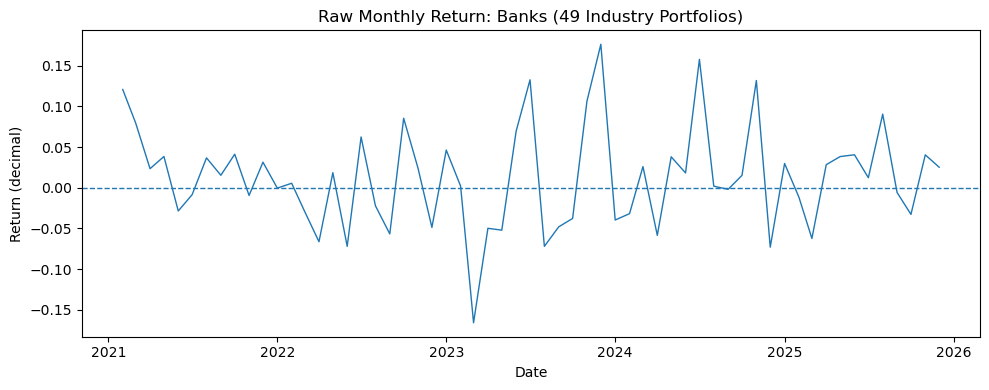

In [138]:
# Plot S3-1: One representative industry return series (raw, before RF subtraction)
col = "Banks" if "Banks" in industry_returns.columns else industry_returns.columns[0]

plt.figure(figsize=(10, 4))
plt.plot(industry_returns.index, industry_returns[col], linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Raw Monthly Return: {col} (49 Industry Portfolios)")
plt.xlabel("Date")
plt.ylabel("Return (decimal)")
plt.tight_layout()
plt.show()

In [139]:
# Download Fama-French 3 Factors (monthly)
ff_factors = pdr.DataReader(
    "F-F_Research_Data_Factors",
    "famafrench"
)

# Extract risk-free rate (RF)
rf = ff_factors[0][["RF"]].copy()

# Convert percentage to decimal
rf = rf / 100

# Convert PeriodIndex to DatetimeIndex (end of month)
rf.index = rf.index.to_timestamp()

rf.head()

/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71837/3412400182.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = pdr.DataReader(
/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71837/3412400182.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = pdr.DataReader(


,RF
Date,
2021-02-01,0.0
2021-03-01,0.0
2021-04-01,0.0
2021-05-01,0.0
2021-06-01,0.0


In [140]:
fred_series = {
    "INDPRO": "Industrial Production Index",
    "UNRATE": "Unemployment Rate",
    "CPIAUCSL": "Consumer Price Index",
    "GS10": "10-Year Treasury Yield"
}

fred_series

{'INDPRO': 'Industrial Production Index',
 'UNRATE': 'Unemployment Rate',
 'CPIAUCSL': 'Consumer Price Index',
 'GS10': '10-Year Treasury Yield'}

In [141]:
# Section 3.5: Download macroeconomic data from FRED

start_date = industry_returns.index.min()
end_date = industry_returns.index.max()

macro_data = pdr.DataReader(
    list(fred_series.keys()),
    "fred",
    start=start_date,
    end=end_date
)

macro_data.head()

,INDPRO,UNRATE,CPIAUCSL,GS10
DATE,,,,
2021-02-01,95.6149,6.2,263.579,1.26
2021-03-01,98.3856,6.1,264.961,1.61
2021-04-01,98.5587,6.1,266.614,1.64
2021-05-01,99.4333,5.8,268.383,1.62
2021-06-01,99.7987,5.9,270.654,1.52


In [142]:
# Section 3.6: Convert macro variables to monthly frequency

# Use end-of-month values
macro_monthly = macro_data.resample("M").last()

macro_monthly.head()

/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71837/3527454021.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  macro_monthly = macro_data.resample("M").last()


,INDPRO,UNRATE,CPIAUCSL,GS10
DATE,,,,
2021-02-28,95.6149,6.2,263.579,1.26
2021-03-31,98.3856,6.1,264.961,1.61
2021-04-30,98.5587,6.1,266.614,1.64
2021-05-31,99.4333,5.8,268.383,1.62
2021-06-30,99.7987,5.9,270.654,1.52


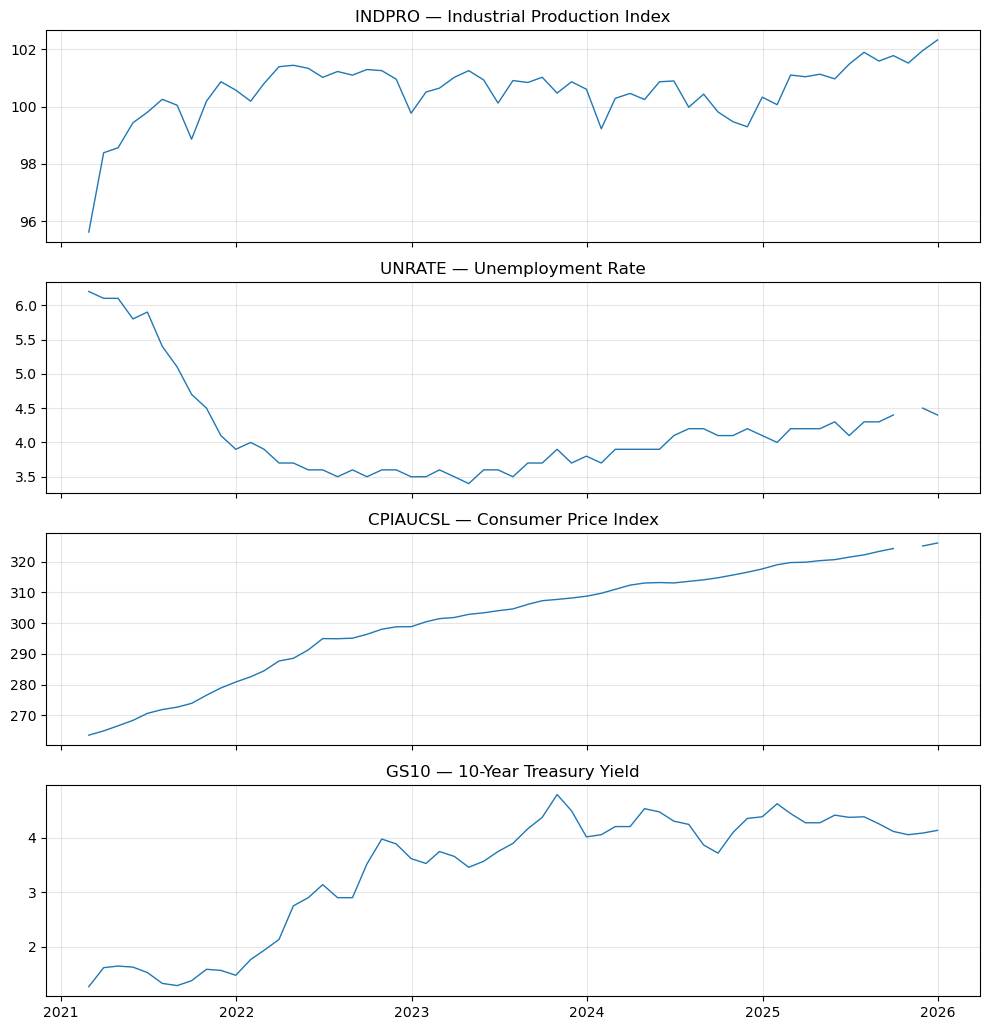

In [143]:
# Plot S3-2: Macroeconomic time series (monthly, end-of-month)
vars_to_plot = ["INDPRO", "UNRATE", "CPIAUCSL", "GS10"]
vars_to_plot = [v for v in vars_to_plot if v in macro_monthly.columns]

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(10, 2.6 * len(vars_to_plot)), sharex=True)
if len(vars_to_plot) == 1:
    axes = [axes]

for ax, v in zip(axes, vars_to_plot):
    ax.plot(macro_monthly.index, macro_monthly[v], linewidth=1)
    ax.set_title(f"{v} — {fred_series.get(v, '')}".strip())
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [144]:
# Section 3.7: Sanity checks

print("Industry returns shape:", industry_returns.shape)
print("Risk-free rate shape:", rf.shape)
print("Macro data shape:", macro_monthly.shape)

print("\nDate ranges:")
print("Industry returns:", industry_returns.index.min(), "to", industry_returns.index.max())
print("Risk-free rate:", rf.index.min(), "to", rf.index.max())
print("Macro data:", macro_monthly.index.min(), "to", macro_monthly.index.max())

Industry returns shape: (59, 49)
Risk-free rate shape: (59, 1)
Macro data shape: (59, 4)

Date ranges:
Industry returns: 2021-02-01 00:00:00 to 2025-12-01 00:00:00
Risk-free rate: 2021-02-01 00:00:00 to 2025-12-01 00:00:00
Macro data: 2021-02-28 00:00:00 to 2025-12-31 00:00:00


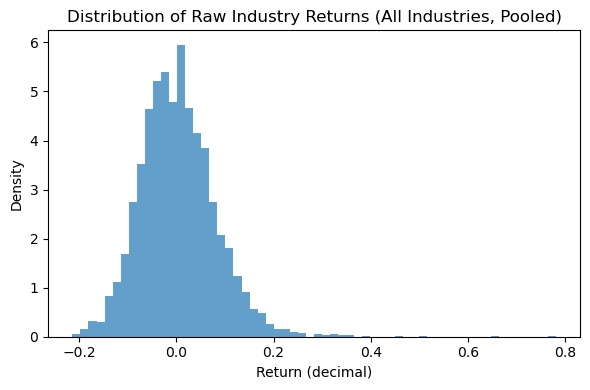

In [145]:
# Plot S3-3: Distribution of raw industry returns (pooled across industries & time)
vals = industry_returns.stack().dropna()

plt.figure(figsize=(6, 4))
plt.hist(vals, bins=60, density=True, alpha=0.7)
plt.title("Distribution of Raw Industry Returns (All Industries, Pooled)")
plt.xlabel("Return (decimal)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


## Section 4 — Data alignment and cleaning

Align time indices, construct excess returns, and perform basic missing-value diagnostics. The code cells that follow adjust indexes and check shapes/NA counts.


In [146]:
# Section 4.1: Align all data to month-end timestamps

from pandas.tseries.offsets import MonthEnd

# Ensure industry returns are at month-end
industry_returns.index = industry_returns.index + MonthEnd(0)

# Ensure risk-free rate is at month-end
rf.index = rf.index + MonthEnd(0)

# Macro data is already month-end due to resample("M").last()

# Quick check
print(industry_returns.index[:3])
print(rf.index[:3])
print(macro_monthly.index[:3])

DatetimeIndex(['2021-02-28', '2021-03-31', '2021-04-30'], dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2021-02-28', '2021-03-31', '2021-04-30'], dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2021-02-28', '2021-03-31', '2021-04-30'], dtype='datetime64[ns]', name='DATE', freq='ME')


In [147]:
# Section 4.2: Align datasets to common date range

common_index = industry_returns.index

industry_returns = industry_returns.loc[common_index]
rf = rf.loc[common_index]
macro_monthly = macro_monthly.loc[common_index]

# Sanity check
print(industry_returns.shape)
print(rf.shape)
print(macro_monthly.shape)


(59, 49)
(59, 1)
(59, 4)


In [148]:
# Section 4.3: Construct excess returns for industry portfolios

# Subtract risk-free rate from each industry return
excess_returns = industry_returns.sub(rf["RF"], axis=0)

excess_returns.head()


,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-28,0.0265,0.0392,-0.0207,0.0558,0.0536,0.0066,0.1658,0.1417,0.0768,0.1256,...,0.0228,0.1705,0.1424,0.0273,0.1069,0.1209,0.0948,0.1408,0.0761,0.1027
2021-03-31,0.0536,0.0272,0.0289,0.0575,0.1086,-0.0024,0.0065,0.0740,0.0555,0.0431,...,0.1184,0.0903,0.0780,0.0983,0.0564,0.0796,0.0687,0.0024,0.0430,0.0651
2021-04-30,0.0151,0.0153,-0.0080,0.0812,-0.0201,0.0337,0.0394,0.0301,0.0780,0.0878,...,0.0690,-0.0157,0.0187,0.0284,0.0716,0.0235,0.0442,0.0028,0.0534,0.0164
2021-05-31,-0.0238,0.0414,0.0838,0.0636,-0.0260,0.0433,0.0744,0.0396,0.0181,-0.0134,...,0.0009,0.0105,0.1008,0.0565,-0.0148,0.0385,0.0057,0.0645,0.0480,0.0141
2021-06-30,0.0061,-0.0027,0.0418,-0.0229,0.0326,0.0298,0.0108,0.0199,-0.0008,0.0218,...,-0.0315,-0.0629,-0.0103,0.0346,0.0158,-0.0285,-0.0164,0.0206,0.0263,0.0127


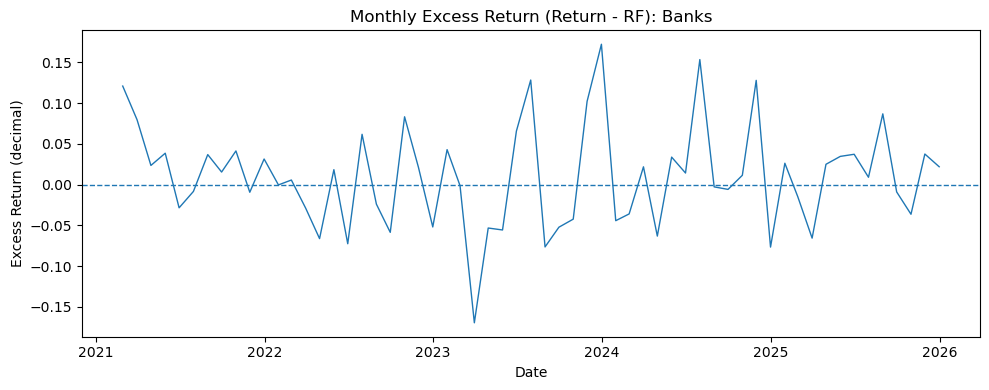

In [149]:
# Plot S4-1: One representative industry excess return series
col = "Banks" if "Banks" in excess_returns.columns else excess_returns.columns[0]

plt.figure(figsize=(10, 4))
plt.plot(excess_returns.index, excess_returns[col], linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Monthly Excess Return (Return - RF): {col}")
plt.xlabel("Date")
plt.ylabel("Excess Return (decimal)")
plt.tight_layout()
plt.show()

In [150]:
# Section 4.4: Missing value diagnostics

print("Missing values in excess returns:")
print(excess_returns.isna().sum().sum())

print("\nMissing values in macro variables:")
print(macro_monthly.isna().sum())

Missing values in excess returns:
0

Missing values in macro variables:
INDPRO      0
UNRATE      1
CPIAUCSL    1
GS10        0
dtype: int64


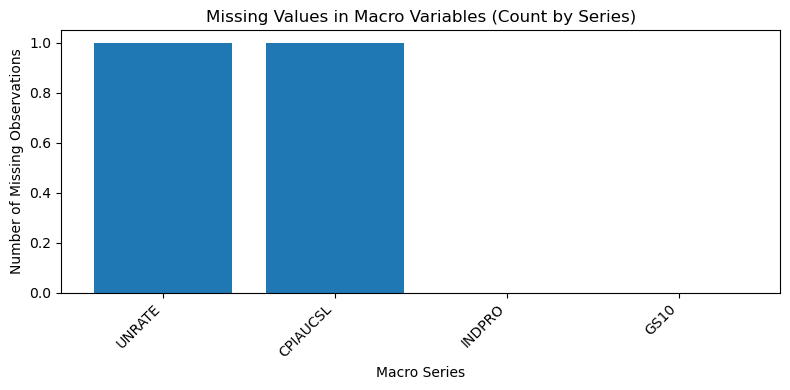

In [151]:
# Plot S4-2: Missing values per macro variable (bar chart)
na_macro = macro_monthly.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(na_macro.index.astype(str), na_macro.values)
plt.title("Missing Values in Macro Variables (Count by Series)")
plt.xlabel("Macro Series")
plt.ylabel("Number of Missing Observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [152]:
# Section 4.5: Final data overview after cleaning and alignment

print("Excess returns shape:", excess_returns.shape)
print("Macro variables shape:", macro_monthly.shape)

print("\nDate range:")
print(excess_returns.index.min(), "to", excess_returns.index.max())


Excess returns shape: (59, 49)
Macro variables shape: (59, 4)

Date range:
2021-02-28 00:00:00 to 2025-12-31 00:00:00


## Section 5 — Feature engineering

Construct momentum and volatility features at multiple horizons and create lagged macroeconomic predictors. The following cells build rolling aggregates and align features with targets.


In [153]:
# Section 5.1: Setup for feature engineering

returns = excess_returns.copy()
macro = macro_monthly.copy()

In [154]:
# Section 5.2: Momentum features

momentum_windows = [3, 6, 12]

momentum_features = {}

for w in momentum_windows:
    momentum_features[f"mom_{w}m"] = (
        returns
        .rolling(window=w)
        .sum()
        .shift(1)
    )

# Combine into a single MultiIndex DataFrame
momentum_df = pd.concat(momentum_features, axis=1)

momentum_df.head()

mom_3m                                                          \
             Agric    Food    Soda    Beer   Smoke    Toys     Fun   Books   
Date                                                                         
2021-02-28     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2021-03-31     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2021-04-30     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2021-05-31  0.0952  0.0817  0.0002  0.1945  0.1421  0.0379  0.2117  0.2458   
2021-06-30  0.0449  0.0839  0.1047  0.2023  0.0625  0.0746  0.1203  0.1437   

                            ... mom_12m                                      \
             Hshld   Clths  ...   Boxes Trans Whlsl Rtail Meals Banks Insur   
Date                        ...                                               
2021-02-28     NaN     NaN  ...     NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2021-03-31     NaN     NaN  ...     NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2021-04-30     NaN     NaN  ...     NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2021-05-31  0.2103  0.2565  ...     NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2021-06-30  0.1516  0.1175  ...     NaN   NaN   NaN   NaN   NaN   NaN   NaN   

                            
           RlEst Fin Other  
Date                        
2021-02-28   NaN NaN   NaN  
2021-03-31   NaN NaN   NaN  
2021-04-30   NaN NaN   NaN  
2021-05-31   NaN NaN   NaN  
2021-06-30   NaN NaN   NaN  

[5 rows x 147 columns]

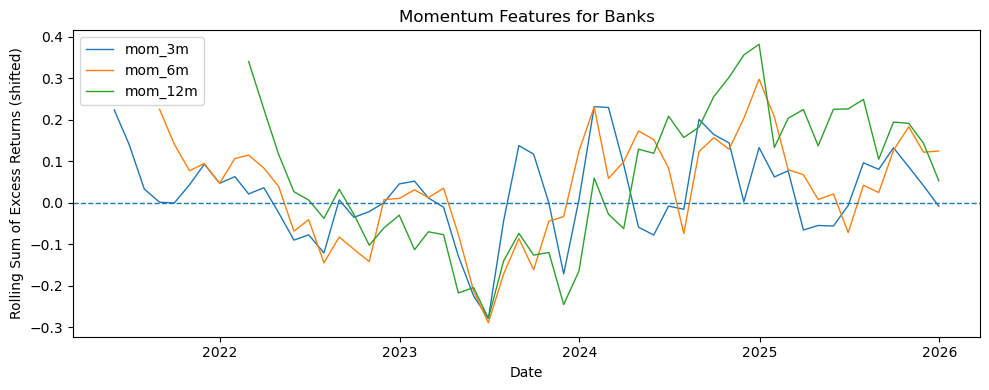

In [155]:
# --- Plot after Cell 18: Momentum time series (3m/6m/12m) for one industry ---

col = "Banks" if "Banks" in returns.columns else returns.columns[0]

# momentum_df columns are MultiIndex: (feature_name, industry)
mom_one = momentum_df.xs(col, level=1, axis=1)

plt.figure(figsize=(10, 4))
for c in mom_one.columns:
    plt.plot(mom_one.index, mom_one[c], linewidth=1, label=c)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Momentum Features for {col}")
plt.xlabel("Date")
plt.ylabel("Rolling Sum of Excess Returns (shifted)")
plt.legend()
plt.tight_layout()
plt.show()

In [156]:
# Section 5.3: Volatility features

vol_windows = [3, 6, 12]

vol_features = {}

for w in vol_windows:
    vol_features[f"vol_{w}m"] = (
        returns
        .rolling(window=w)
        .std()
        .shift(1)
    )

vol_df = pd.concat(vol_features, axis=1)

vol_df.head()

vol_3m                                                    \
               Agric      Food      Soda      Beer     Smoke      Toys   
Date                                                                     
2021-02-28       NaN       NaN       NaN       NaN       NaN       NaN   
2021-03-31       NaN       NaN       NaN       NaN       NaN       NaN   
2021-04-30       NaN       NaN       NaN       NaN       NaN       NaN   
2021-05-31  0.019776  0.011950  0.025765  0.014199  0.064576  0.018791   
2021-06-30  0.038700  0.013067  0.046193  0.012306  0.076065  0.024097   

                                                    ... vol_12m              \
                 Fun     Books     Hshld     Clths  ...   Boxes Trans Whlsl   
Date                                                ...                       
2021-02-28       NaN       NaN       NaN       NaN  ...     NaN   NaN   NaN   
2021-03-31       NaN       NaN       NaN       NaN  ...     NaN   NaN   NaN   
2021-04-30       NaN       NaN       NaN       NaN  ...     NaN   NaN   NaN   
2021-05-31  0.084099  0.056221  0.012658  0.041298  ...     NaN   NaN   NaN   
2021-06-30  0.033955  0.023097  0.030257  0.050715  ...     NaN   NaN   NaN   

                                                    
           Rtail Meals Banks Insur RlEst Fin Other  
Date                                                
2021-02-28   NaN   NaN   NaN   NaN   NaN NaN   NaN  
2021-03-31   NaN   NaN   NaN   NaN   NaN NaN   NaN  
2021-04-30   NaN   NaN   NaN   NaN   NaN NaN   NaN  
2021-05-31   NaN   NaN   NaN   NaN   NaN NaN   NaN  
2021-06-30   NaN   NaN   NaN   NaN   NaN NaN   NaN  

[5 rows x 147 columns]

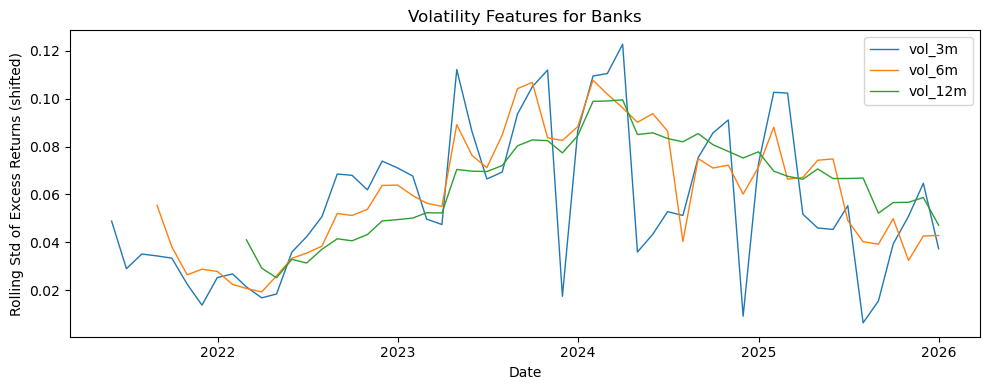

In [157]:
# --- Plot after Cell 19: Volatility time series (3m/6m/12m) for one industry ---

col = "Banks" if "Banks" in returns.columns else returns.columns[0]

# vol_df columns are MultiIndex: (feature_name, industry)
vol_one = vol_df.xs(col, level=1, axis=1)

plt.figure(figsize=(10, 4))
for c in vol_one.columns:
    plt.plot(vol_one.index, vol_one[c], linewidth=1, label=c)

plt.title(f"Volatility Features for {col}")
plt.xlabel("Date")
plt.ylabel("Rolling Std of Excess Returns (shifted)")
plt.legend()
plt.tight_layout()
plt.show()

In [158]:
# Section 5.4: Lagged macroeconomic variables

macro_lags = [1, 3, 6]

macro_features = {}

for lag in macro_lags:
    macro_features[f"macro_lag_{lag}"] = macro.shift(lag)

macro_lagged = pd.concat(macro_features, axis=1)

macro_lagged.head()

macro_lag_1                       macro_lag_3                  \
                INDPRO UNRATE CPIAUCSL  GS10      INDPRO UNRATE CPIAUCSL   
Date                                                                       
2021-02-28         NaN    NaN      NaN   NaN         NaN    NaN      NaN   
2021-03-31     95.6149    6.2  263.579  1.26         NaN    NaN      NaN   
2021-04-30     98.3856    6.1  264.961  1.61         NaN    NaN      NaN   
2021-05-31     98.5587    6.1  266.614  1.64     95.6149    6.2  263.579   
2021-06-30     99.4333    5.8  268.383  1.62     98.3856    6.1  264.961   

                 macro_lag_6                       
            GS10      INDPRO UNRATE CPIAUCSL GS10  
Date                                               
2021-02-28   NaN         NaN    NaN      NaN  NaN  
2021-03-31   NaN         NaN    NaN      NaN  NaN  
2021-04-30   NaN         NaN    NaN      NaN  NaN  
2021-05-31  1.26         NaN    NaN      NaN  NaN  
2021-06-30  1.61         NaN    NaN      NaN  NaN

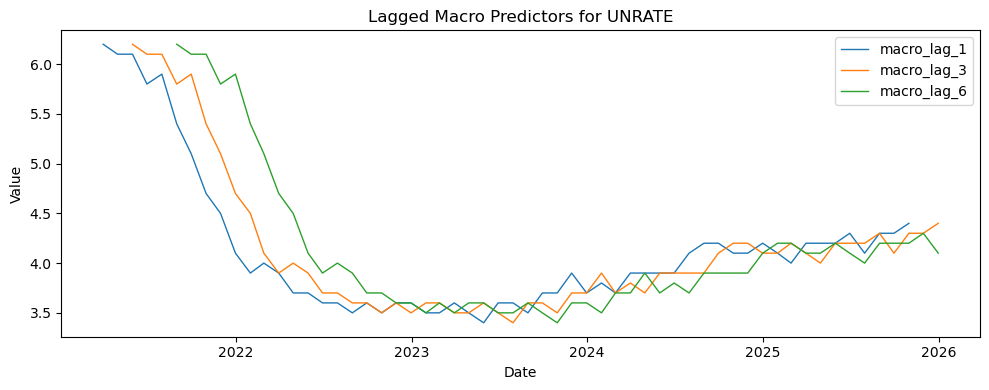

In [159]:
# --- Plot after Cell 20: Lagged macro features (1/3/6) for one macro variable ---

# pick a macro series safely (prefer UNRATE if exists)
macro_var = "UNRATE" if "UNRATE" in macro.columns else macro.columns[0]

# macro_lagged columns are MultiIndex: (macro_lag_k, macro_var)
macro_one = macro_lagged.xs(macro_var, level=1, axis=1)

plt.figure(figsize=(10, 4))
for c in macro_one.columns:
    plt.plot(macro_one.index, macro_one[c], linewidth=1, label=c)

plt.title(f"Lagged Macro Predictors for {macro_var}")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

In [160]:
# Section 5.5: Align features and target variable

# Combine all feature blocks
features = pd.concat(
    [momentum_df, vol_df],
    axis=1
)

# Align everything on time index
features = features.loc[returns.index]
macro_lagged = macro_lagged.loc[returns.index]
returns = returns.loc[returns.index]

# Final sanity check
print(features.shape)
print(macro_lagged.shape)
print(returns.shape)

(59, 294)
(59, 12)
(59, 49)


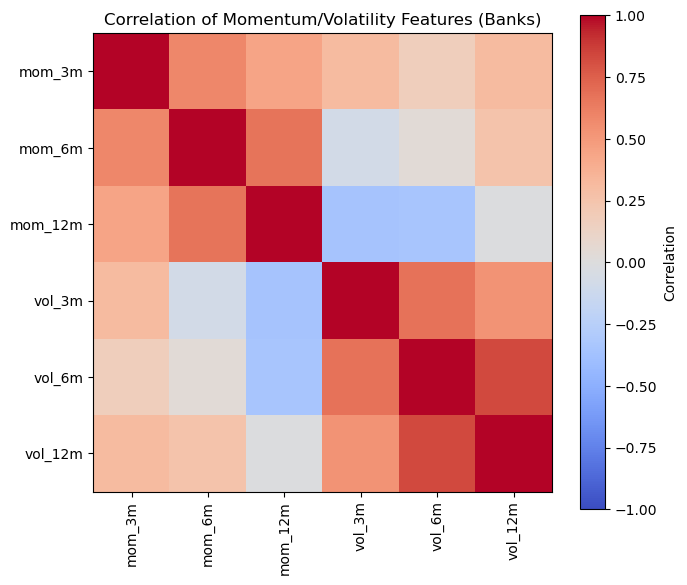

In [161]:
# --- Plot after Cell 21: Correlation heatmap of mom/vol features for one industry ---

col = "Banks" if "Banks" in returns.columns else returns.columns[0]

# features columns are MultiIndex: (feature_name, industry)
feat_one = features.xs(col, level=1, axis=1).dropna()

corr = feat_one.corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title(f"Correlation of Momentum/Volatility Features ({col})")
plt.tight_layout()
plt.show()

In [162]:
# Section 5.6: Missing values after feature engineering

print("Missing values in features:")
print(features.isna().sum().sum())

print("\nMissing values in macro features:")
print(macro_lagged.isna().sum().sum())

Missing values in features:
2058

Missing values in macro features:
42


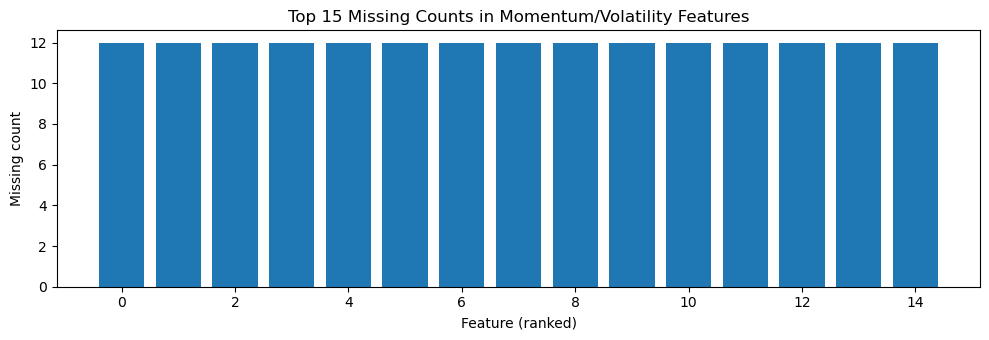

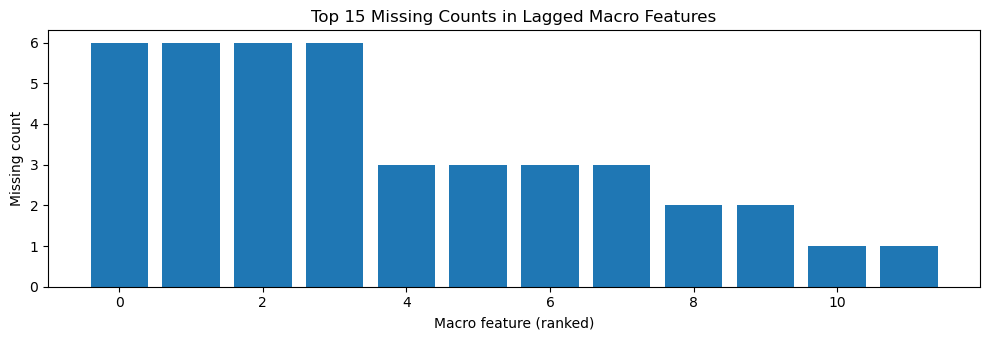

In [163]:
# --- Plot after Cell 22: Missing values by feature (top 15) ---

na_feat = features.isna().sum().sort_values(ascending=False).head(15)
na_macro = macro_lagged.isna().sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 3.5))
plt.bar(range(len(na_feat)), na_feat.values)
plt.title("Top 15 Missing Counts in Momentum/Volatility Features")
plt.xlabel("Feature (ranked)")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.5))
plt.bar(range(len(na_macro)), na_macro.values)
plt.title("Top 15 Missing Counts in Lagged Macro Features")
plt.xlabel("Macro feature (ranked)")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

## Section 6 — Model specification

Define baseline and regularised linear models plus a conservative Random Forest. Hyperparameter choices aim to limit overfitting in an out-of-sample evaluation.


In [164]:
# Section 6.1: Libraries for model specification

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

In [165]:
# Section 6.2: OLS model (baseline)

ols_model = LinearRegression()

# Ridge model (regularised linear regression)
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0, fit_intercept=True)

In [166]:
# Section 6.3: Regularised linear models

ridge_model = Ridge()
lasso_model = Lasso(max_iter=10000)

ridge_param_grid = {
    "alpha": [0.1, 1.0, 10.0, 100.0]
}

lasso_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1.0]
}

# Section 6.3: Random Forest regression model

from sklearn.ensemble import RandomForestRegressor

# Conservative specification to avoid overfitting
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

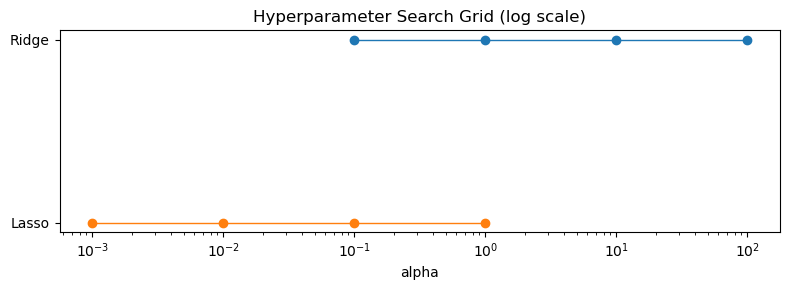

In [167]:
# --- Plot S6-1: Hyperparameter grids for Ridge & Lasso ---

ridge_alphas = ridge_param_grid["alpha"]
lasso_alphas = lasso_param_grid["alpha"]

plt.figure(figsize=(8, 3))
plt.plot(ridge_alphas, [1]*len(ridge_alphas), marker="o", linewidth=1, label="Ridge alpha grid")
plt.plot(lasso_alphas, [0]*len(lasso_alphas), marker="o", linewidth=1, label="Lasso alpha grid")
plt.yticks([0, 1], ["Lasso", "Ridge"])
plt.xscale("log")
plt.title("Hyperparameter Search Grid (log scale)")
plt.xlabel("alpha")
plt.tight_layout()
plt.show()

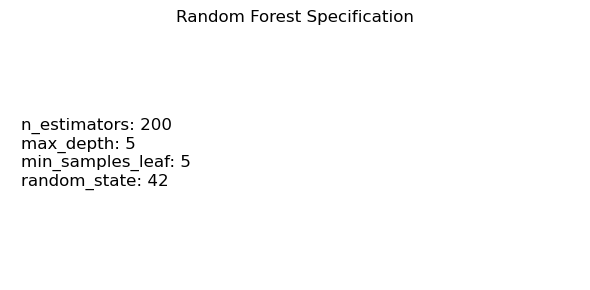

In [168]:
# --- Plot S6-2: RF configuration card (for slides) ---

rf_params = rf_model.get_params()

text = "\n".join([
    f"n_estimators: {rf_params.get('n_estimators')}",
    f"max_depth: {rf_params.get('max_depth')}",
    f"min_samples_leaf: {rf_params.get('min_samples_leaf')}",
    f"random_state: {rf_params.get('random_state')}",
])

plt.figure(figsize=(6, 3))
plt.axis("off")
plt.title("Random Forest Specification")
plt.text(0.02, 0.65, text, fontsize=12, va="top")
plt.tight_layout()
plt.show()

Hyperparameters are deliberately fixed rather than tuned to avoid excessive data mining and overfitting in a small-sample out-of-sample evaluation.

In [169]:
# Section 6.4: Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

In [170]:
# Section 6.5: Model registry

models = {
    "OLS": ols_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "RandomForest": rf_model
}

param_grids = {
    "Ridge": ridge_param_grid,
    "Lasso": lasso_param_grid
}

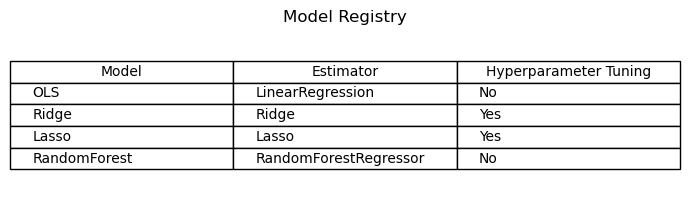

In [171]:
# --- Plot S6-3: Model registry table (slides-friendly) ---

rows = []
for name, model in models.items():
    tuned = "Yes" if name in param_grids else "No"
    rows.append([name, model.__class__.__name__, tuned])

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.axis("off")
table = ax.table(
    cellText=rows,
    colLabels=["Model", "Estimator", "Hyperparameter Tuning"],
    cellLoc="left",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.3)
ax.set_title("Model Registry")
plt.tight_layout()
plt.show()

In [172]:
# Section 6.6: Sanity check (no fitting here)

print("Defined models:")
for name in models:
    print("-", name)

print("\nModels with hyperparameter tuning:")
for name in param_grids:
    print("-", name)


Defined models:
- OLS
- Ridge
- Lasso
- RandomForest

Models with hyperparameter tuning:
- Ridge
- Lasso


An expanding-window scheme is adopted to reflect a realistic learning process, where the investor updates beliefs as more data become available over time rather than discarding past information.

## Section 7 — Backtesting design

Specify expanding-window forecasting, benchmarks, and the procedure used to produce one-step-ahead predictions across industries. The code cells implement the out-of-sample loop and benchmark construction.


In [173]:
# Section 7.1: Backtesting design

# Choose expanding window (can be changed to rolling later)
window_type = "expanding"

# Minimum initial training window (e.g. 24 months)
min_train_size = 24

# Target variable
y = returns.copy()   # excess returns

# Feature blocks
X_industry = features.copy()      # momentum + volatility (industry-specific)
X_macro = macro_lagged.copy()     # macro variables (common across industries)

In [174]:
# Section 7.2: Historical mean benchmark (expanding)

benchmark_pred = {}

for t in range(min_train_size, len(y)):
    train_slice = y.iloc[:t]
    benchmark_pred[y.index[t]] = train_slice.mean()

benchmark_pred = pd.DataFrame(benchmark_pred).T
benchmark_pred.columns = y.columns

benchmark_pred.head()

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
2023-02-28,0.003775,-0.003604,-0.006804,-0.007583,0.001246,-0.023038,0.003475,0.011763,-0.003300,-0.001896,...,0.004792,0.008763,0.017550,-0.004900,0.009017,0.011296,0.006487,0.006062,0.010037,-0.001617
2023-03-31,-0.001592,-0.004948,-0.007744,-0.009220,0.000980,-0.025952,0.002644,0.010140,-0.004196,-0.004248,...,0.002964,0.007240,0.016112,-0.007100,0.008312,0.010792,0.007040,0.004280,0.008824,-0.002992
2023-04-30,-0.004481,-0.005246,-0.006154,-0.010900,-0.000781,-0.026658,-0.000008,0.005181,-0.006412,-0.006258,...,-0.000019,0.007304,0.013658,-0.010142,0.007377,0.003854,0.004623,0.002992,0.006377,-0.004115
2023-05-31,-0.008204,-0.005200,-0.007619,-0.010885,0.001904,-0.026996,0.000281,0.003559,-0.007059,-0.006548,...,-0.002330,0.006207,0.012585,-0.011585,0.007404,0.001737,0.004141,0.002074,0.005633,-0.003319
2023-06-30,-0.009764,-0.007175,-0.002775,-0.011386,-0.001679,-0.029182,-0.002486,0.004182,-0.009536,-0.009596,...,-0.004750,0.005514,0.011996,-0.013314,0.007143,-0.000314,0.003493,0.003864,0.004982,-0.003696


In [175]:
# Section 7.3: OLS rolling / expanding window prediction

ols_predictions = {}

for t in range(min_train_size, len(y)):
    
    date = y.index[t]
    
    # Training data
    y_train = y.iloc[:t]
    X_ind_train = X_industry.iloc[:t]
    X_macro_train = X_macro.iloc[:t]
    
    # Test data (one-step-ahead)
    X_ind_test = X_industry.iloc[t:t+1]
    X_macro_test = X_macro.iloc[t:t+1]
    
    preds_t = {}
    
    # Loop over industries
    for industry in y.columns:
        
        # Industry-specific features
        X_train = pd.concat(
            [X_ind_train.xs(industry, level=1, axis=1), X_macro_train],
            axis=1
        )
        
        X_test = pd.concat(
            [X_ind_test.xs(industry, level=1, axis=1), X_macro_test],
            axis=1
        )
        
        y_train_ind = y_train[industry]
        
        # Drop NA (natural from rolling / lags)
        valid_idx = X_train.dropna().index
        X_train = X_train.loc[valid_idx]
        y_train_ind = y_train_ind.loc[valid_idx]

        # IMPORTANT: make column names compatible with sklearn
        X_train.columns = X_train.columns.astype(str)
        X_test.columns = X_test.columns.astype(str)

        # Fit OLS
        ols_model.fit(X_train, y_train_ind)

        # Predict only if X_test has no missing values
        if X_test.isna().any().any():
            preds_t[industry] = np.nan
        else:
            preds_t[industry] = ols_model.predict(X_test)[0]

    
        ols_predictions[date] = preds_t

ols_predictions = pd.DataFrame(ols_predictions).T
ols_predictions.head()

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
2023-02-28,-0.129408,-0.083344,-0.226258,-0.031113,-0.136086,-0.020482,-0.015619,0.100807,0.172843,0.010134,...,-0.072761,-0.041035,-0.017061,0.061043,-0.044365,-0.085180,-0.106430,-0.000683,-0.081289,0.032850
2023-03-31,0.089325,-0.055645,-0.046519,0.059889,-0.218556,0.060529,0.091471,0.520430,0.324181,0.217724,...,0.038757,0.083816,0.170764,0.017088,0.075426,-0.154177,-0.077007,0.095845,0.070107,-0.000529
2023-04-30,-0.129503,-0.004187,0.278607,-0.032813,-0.196314,-0.155986,-0.086102,0.205422,0.039451,-0.047966,...,-0.100685,-0.153664,-0.106236,-0.201259,-0.054775,-0.289069,-0.253372,-0.278688,-0.270024,-0.093894
2023-05-31,-0.157658,-0.066555,-0.279534,0.025541,-0.022747,-0.259135,-0.135386,0.010892,-0.242345,-0.181694,...,-0.052304,-0.130290,-0.155914,-0.421720,-0.017425,0.153234,0.051778,-0.294891,-0.097576,-0.016903
2023-06-30,-0.118264,-0.184292,0.117619,-0.228197,-0.118189,-0.174666,-0.118917,-0.202077,-0.211349,-0.210485,...,-0.086508,0.013536,-0.129470,-0.266323,-0.085542,-0.228593,-0.238639,0.070525,-0.001057,0.017575


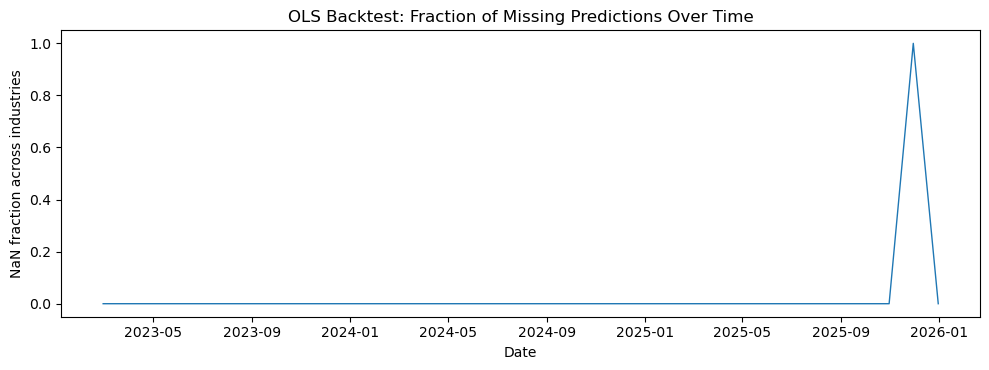

In [176]:
# --- Plot S7-1: Prediction availability over time (OLS) ---

nan_rate = ols_predictions.isna().mean(axis=1)  # fraction of industries missing each date

plt.figure(figsize=(10, 3.8))
plt.plot(nan_rate.index, nan_rate.values, linewidth=1)
plt.title("OLS Backtest: Fraction of Missing Predictions Over Time")
plt.xlabel("Date")
plt.ylabel("NaN fraction across industries")
plt.tight_layout()
plt.show()

In [177]:
# Section 7.4: Align predictions and realized returns

y_oos = y.loc[ols_predictions.index]

benchmark_oos = benchmark_pred.loc[ols_predictions.index]

print(ols_predictions.shape)
print(y_oos.shape)
print(benchmark_oos.shape)

(35, 49)
(35, 49)
(35, 49)


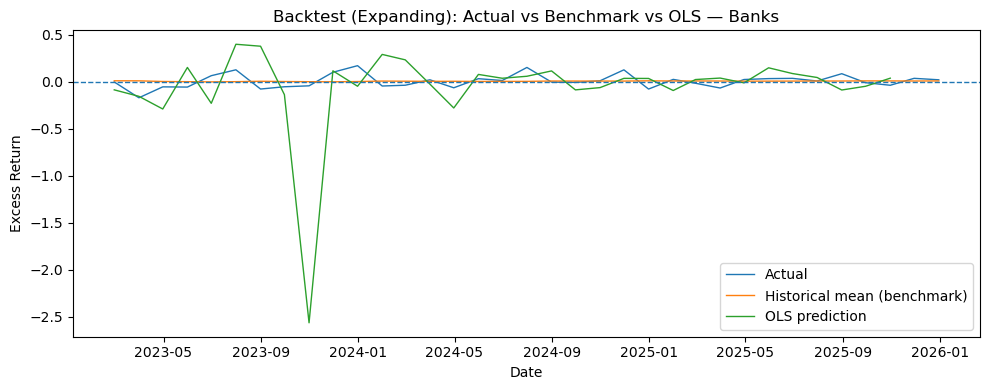

In [178]:
# --- Plot S7-2: Actual vs Benchmark vs OLS prediction (one industry) ---

industry = "Banks" if "Banks" in y_oos.columns else y_oos.columns[0]

plt.figure(figsize=(10, 4))
plt.plot(y_oos.index, y_oos[industry], label="Actual", linewidth=1)
plt.plot(benchmark_oos.index, benchmark_oos[industry], label="Historical mean (benchmark)", linewidth=1)
plt.plot(ols_predictions.index, ols_predictions[industry], label="OLS prediction", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Backtest (Expanding): Actual vs Benchmark vs OLS — {industry}")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.tight_layout()
plt.show()

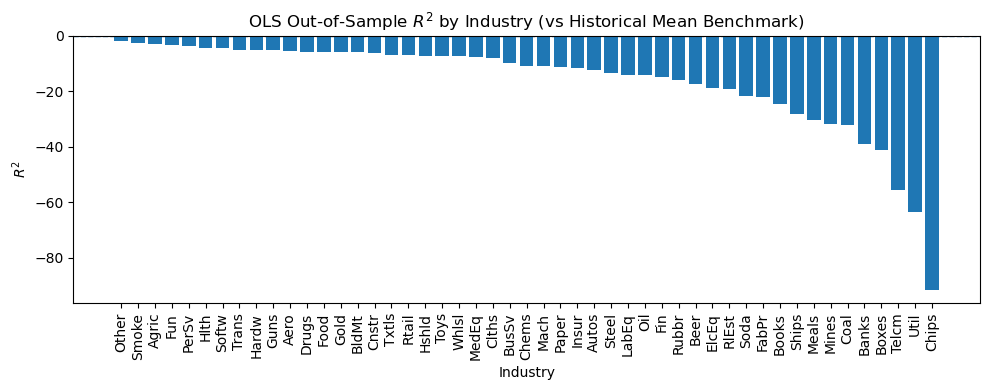

In [179]:
# --- Plot S7-3: OOS R^2 by industry (OLS vs benchmark) ---

# Align and drop rows where OLS prediction is NaN (per industry handled below)
r2_by_industry = {}

for industry in y_oos.columns:
    df_tmp = pd.concat([y_oos[industry], ols_predictions[industry], benchmark_oos[industry]], axis=1)
    df_tmp.columns = ["y", "y_hat", "bench"]
    df_tmp = df_tmp.dropna()

    if len(df_tmp) < 10:
        r2_by_industry[industry] = np.nan
        continue

    ss_res = ((df_tmp["y"] - df_tmp["y_hat"]) ** 2).sum()
    ss_tot = ((df_tmp["y"] - df_tmp["bench"]) ** 2).sum()
    r2_by_industry[industry] = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

r2_series = pd.Series(r2_by_industry).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(r2_series.index.astype(str), r2_series.values)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("OLS Out-of-Sample $R^2$ by Industry (vs Historical Mean Benchmark)")
plt.xlabel("Industry")
plt.ylabel("$R^2$")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [180]:
# Section 7.5: Ridge rolling / expanding window prediction

ridge_predictions = {}

for t in range(min_train_size, len(y)):
    
    date = y.index[t]
    
    # Training data
    y_train = y.iloc[:t]
    X_ind_train = X_industry.iloc[:t]
    X_macro_train = X_macro.iloc[:t]
    
    # Test data (one-step-ahead)
    X_ind_test = X_industry.iloc[t:t+1]
    X_macro_test = X_macro.iloc[t:t+1]
    
    preds_t = {}
    
    # Loop over industries
    for industry in y.columns:
        
        # Industry-specific + macro features
        X_train = pd.concat(
            [X_ind_train.xs(industry, level=1, axis=1), X_macro_train],
            axis=1
        )
        
        X_test = pd.concat(
            [X_ind_test.xs(industry, level=1, axis=1), X_macro_test],
            axis=1
        )
        
        y_train_ind = y_train[industry]
        
        # Drop NA from training data
        valid_idx = X_train.dropna().index
        X_train = X_train.loc[valid_idx]
        y_train_ind = y_train_ind.loc[valid_idx]
        
        # Make sklearn-compatible column names
        X_train.columns = X_train.columns.astype(str)
        X_test.columns = X_test.columns.astype(str)
        
        # Fit Ridge
        ridge_model.fit(X_train, y_train_ind)
        
        # Predict (only if no NA in test set)
        if X_test.isna().any().any():
            preds_t[industry] = np.nan
        else:
            preds_t[industry] = ridge_model.predict(X_test)[0]
    
    ridge_predictions[date] = preds_t

ridge_predictions = pd.DataFrame(ridge_predictions).T
ridge_predictions.head()

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
2023-02-28,0.064679,-0.010298,-0.015123,-0.047034,0.008093,0.022389,0.044762,0.023938,0.069238,0.038677,...,0.002384,0.039270,0.017339,0.049286,0.067032,-0.000346,0.017815,0.043161,0.025769,0.024322
2023-03-31,-0.048470,0.005714,-0.028132,-0.015259,0.067836,-0.034371,0.011087,0.052921,0.047590,0.050810,...,0.027141,0.000553,0.039514,0.023602,0.032702,0.009662,0.018931,0.022518,0.022398,-0.012236
2023-04-30,-0.117022,-0.013585,-0.031449,-0.073408,0.022611,-0.085421,-0.046996,-0.058464,-0.034489,-0.039405,...,-0.030198,-0.033315,-0.020495,-0.058876,-0.024965,-0.073279,-0.005034,-0.031506,-0.027227,-0.023876
2023-05-31,-0.110329,-0.030858,-0.048627,-0.050573,0.036100,-0.095458,-0.053548,-0.078468,-0.043293,-0.061103,...,-0.060059,-0.053034,-0.047908,-0.071271,-0.032926,-0.072655,-0.017879,-0.051482,-0.046162,-0.006686
2023-06-30,-0.011084,-0.037429,0.045682,-0.016608,-0.039810,-0.067206,-0.020926,0.007123,-0.021829,-0.037254,...,-0.024005,0.015529,0.002205,-0.029310,0.006147,-0.051120,0.016180,0.060076,0.001641,0.011650


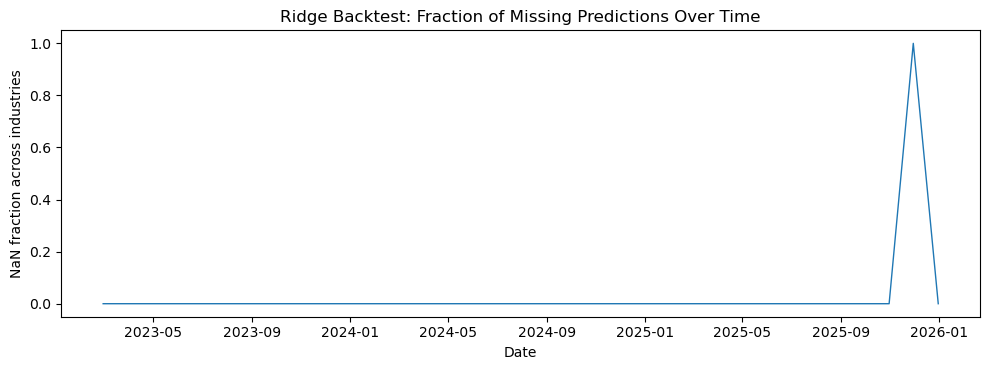

In [181]:
# --- Plot S7-4: Prediction availability over time (Ridge) ---

nan_rate_ridge = ridge_predictions.isna().mean(axis=1)

plt.figure(figsize=(10, 3.8))
plt.plot(nan_rate_ridge.index, nan_rate_ridge.values, linewidth=1)
plt.title("Ridge Backtest: Fraction of Missing Predictions Over Time")
plt.xlabel("Date")
plt.ylabel("NaN fraction across industries")
plt.tight_layout()
plt.show()

In [182]:
# Section 7.6: Align Ridge predictions and realized returns

ridge_y_oos = y.loc[ridge_predictions.index]
ridge_benchmark_oos = benchmark_pred.loc[ridge_predictions.index]

print(ridge_predictions.shape)
print(ridge_y_oos.shape)
print(ridge_benchmark_oos.shape)

(35, 49)
(35, 49)
(35, 49)


In [183]:
# Section 7.7: Random Forest rolling / expanding window prediction

rf_predictions = {}

for t in range(min_train_size, len(y)):
    
    date = y.index[t]
    
    # Training data
    y_train = y.iloc[:t]
    X_ind_train = X_industry.iloc[:t]
    X_macro_train = X_macro.iloc[:t]
    
    # Test data (one-step-ahead)
    X_ind_test = X_industry.iloc[t:t+1]
    X_macro_test = X_macro.iloc[t:t+1]
    
    preds_t = {}
    
    # Loop over industries
    for industry in y.columns:
        
        # Industry-specific + macro features
        X_train = pd.concat(
            [X_ind_train.xs(industry, level=1, axis=1), X_macro_train],
            axis=1
        )
        
        X_test = pd.concat(
            [X_ind_test.xs(industry, level=1, axis=1), X_macro_test],
            axis=1
        )
        
        y_train_ind = y_train[industry]
        
        # Drop NA from training data
        valid_idx = X_train.dropna().index
        X_train = X_train.loc[valid_idx]
        y_train_ind = y_train_ind.loc[valid_idx]
        
        # Make sklearn-compatible column names
        X_train.columns = X_train.columns.astype(str)
        X_test.columns = X_test.columns.astype(str)
        
        # Fit Random Forest
        rf_model.fit(X_train, y_train_ind)
        
        # Predict (only if no NA in test set)
        if X_test.isna().any().any():
            preds_t[industry] = np.nan
        else:
            preds_t[industry] = rf_model.predict(X_test)[0]
    
    rf_predictions[date] = preds_t

rf_predictions = pd.DataFrame(rf_predictions).T
rf_predictions.head()

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
2023-02-28,0.000871,-0.008822,-0.013077,-0.024749,-0.008554,-0.026473,-0.007574,-0.008725,-0.008361,-0.014600,...,-0.006637,-0.002116,0.009513,-0.013212,0.005647,-0.006240,-0.001010,-0.001876,0.002658,-0.009907
2023-03-31,-0.009507,-0.011170,-0.014502,-0.026270,-0.008618,-0.032150,-0.008569,-0.010548,-0.009990,-0.018531,...,-0.009355,-0.004339,0.007105,-0.017357,0.004223,-0.006121,0.000505,-0.004928,0.000495,-0.012102
2023-04-30,-0.014701,-0.011130,-0.010601,-0.028508,-0.011271,-0.032972,-0.012803,-0.019116,-0.014087,-0.021365,...,-0.014498,-0.002912,0.002977,-0.022732,0.002962,-0.019360,-0.003830,-0.006574,-0.003761,-0.013644
2023-05-31,-0.021325,-0.010524,-0.012652,-0.027498,-0.005104,-0.033220,-0.011715,-0.020750,-0.014946,-0.021016,...,-0.017831,-0.004425,0.001590,-0.024677,0.003086,-0.021879,-0.003888,-0.007752,-0.004406,-0.011505
2023-06-30,-0.024666,-0.013703,-0.005047,-0.027567,-0.011029,-0.037344,-0.016304,-0.018824,-0.019300,-0.025766,...,-0.021160,-0.005699,0.000977,-0.027645,0.001983,-0.024000,-0.004882,-0.004995,-0.005303,-0.012132


In [184]:
# Section 7.8: Align Random Forest predictions and realized returns

rf_y_oos = y.loc[rf_predictions.index]
rf_benchmark_oos = benchmark_pred.loc[rf_predictions.index]

print(rf_predictions.shape)
print(rf_y_oos.shape)
print(rf_benchmark_oos.shape)

(35, 49)
(35, 49)
(35, 49)


The benchmark is defined as an expanding-window historical mean, constructed using only information available up to time \(t-1\), ensuring a fair out-of-sample comparison and avoiding look-ahead bias.

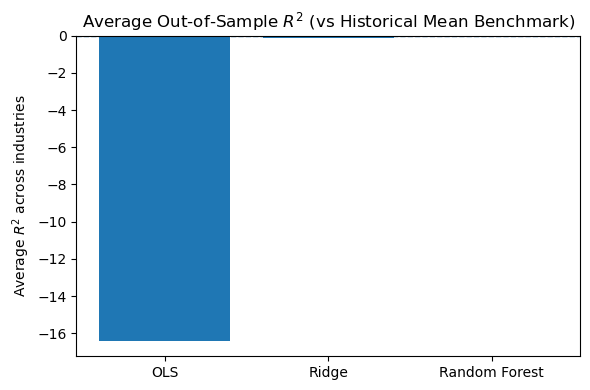

In [185]:
# --- Plot S7-5: Average OOS R^2 comparison across models ---

def oos_r2_avg(y_true_df, y_pred_df, y_bench_df):
    r2_list = []
    for industry in y_true_df.columns:
        df_tmp = pd.concat([y_true_df[industry], y_pred_df[industry], y_bench_df[industry]], axis=1)
        df_tmp.columns = ["y", "y_hat", "bench"]
        df_tmp = df_tmp.dropna()
        if len(df_tmp) < 10:
            continue
        ss_res = ((df_tmp["y"] - df_tmp["y_hat"]) ** 2).sum()
        ss_tot = ((df_tmp["y"] - df_tmp["bench"]) ** 2).sum()
        if ss_tot != 0:
            r2_list.append(1 - ss_res / ss_tot)
    return np.mean(r2_list) if len(r2_list) > 0 else np.nan

avg_r2_ols   = oos_r2_avg(y_oos, ols_predictions, benchmark_oos)
avg_r2_ridge = oos_r2_avg(ridge_y_oos, ridge_predictions, ridge_benchmark_oos)
avg_r2_rf    = oos_r2_avg(rf_y_oos, rf_predictions, rf_benchmark_oos)

vals = [avg_r2_ols, avg_r2_ridge, avg_r2_rf]
labels = ["OLS", "Ridge", "Random Forest"]

plt.figure(figsize=(6, 4))
plt.bar(labels, vals)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Average Out-of-Sample $R^2$ (vs Historical Mean Benchmark)")
plt.ylabel("Average $R^2$ across industries")
plt.tight_layout()
plt.show()

## Section 8 — Evaluation metrics

Define statistical metrics (out-of-sample R^2) and economic metrics (strategy returns, Sharpe ratio, drawdowns) used to compare models. Below we implement helper functions and aggregate industry-level statistics.


In [186]:
# Section 8.1: Function to compute out-of-sample R^2

def oos_r2(y_true, y_pred, y_benchmark):
    """
    Compute out-of-sample R^2 relative to a benchmark.
    All inputs are pandas Series aligned on the same index.
    """
    mask = (~y_true.isna()) & (~y_pred.isna()) & (~y_benchmark.isna())
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    y_benchmark = y_benchmark[mask]
    
    ss_model = ((y_true - y_pred) ** 2).sum()
    ss_benchmark = ((y_true - y_benchmark) ** 2).sum()
    
    return 1 - ss_model / ss_benchmark

In [187]:
# Section 8.2: Industry-level out-of-sample R^2

oos_r2_industry = {}

for industry in y_oos.columns:
    r2 = oos_r2(
        y_true=y_oos[industry],
        y_pred=ols_predictions[industry],
        y_benchmark=benchmark_oos[industry]
    )
    oos_r2_industry[industry] = r2

oos_r2_industry = pd.Series(oos_r2_industry).sort_values(ascending=False)

oos_r2_industry.head(10)

Other   -2.081567
Smoke   -2.489145
Agric   -3.063921
Fun     -3.355996
PerSv   -3.805694
Hlth    -4.294136
Softw   -4.345776
Trans   -5.114874
Hardw   -5.121902
Guns    -5.304670
dtype: float64

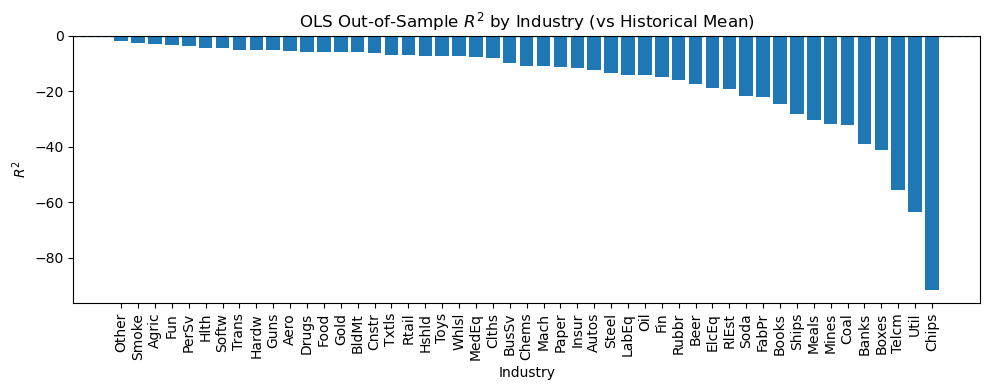

In [188]:
# --- Plot S8-1: OLS out-of-sample R^2 by industry ---

plt.figure(figsize=(10, 4))
plt.bar(oos_r2_industry.index.astype(str), oos_r2_industry.values)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("OLS Out-of-Sample $R^2$ by Industry (vs Historical Mean)")
plt.xlabel("Industry")
plt.ylabel("$R^2$")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [189]:
# Section 8.3: Average out-of-sample R^2 across industries

avg_oos_r2 = oos_r2_industry.mean()

avg_oos_r2

np.float64(-16.41646485064262)

In [190]:
# Section 8.4: Summary table for statistical performance

stat_summary = pd.DataFrame({
    "OOS_R2_OLS": oos_r2_industry
})

stat_summary.describe()

,OOS_R2_OLS
count,49.000000
mean,-16.416465
std,17.406094
min,-91.823167
25%,-19.336817
50%,-10.831611
75%,-5.744906
max,-2.081567


In [191]:
# Section 8.5.1: Ridge industry-level OOS R^2

ridge_oos_r2_industry = {}

for industry in ridge_y_oos.columns:
    r2 = oos_r2(
        y_true=ridge_y_oos[industry],
        y_pred=ridge_predictions[industry],
        y_benchmark=ridge_benchmark_oos[industry]
    )
    ridge_oos_r2_industry[industry] = r2

ridge_oos_r2_industry = pd.Series(ridge_oos_r2_industry).sort_values(ascending=False)
ridge_oos_r2_industry.head(10)

Guns     0.235146
Other    0.230499
Oil      0.114404
Agric    0.106042
Cnstr    0.105512
BusSv    0.040790
Hardw    0.003070
FabPr   -0.022039
Softw   -0.031777
Aero    -0.032447
dtype: float64

In [192]:
# Section 8.5.2: Average OOS R^2 (Ridge)

ridge_avg_oos_r2 = ridge_oos_r2_industry.mean()
ridge_avg_oos_r2

np.float64(-0.14809262576766016)

In [193]:
# Section 8.6.1: Random Forest industry-level OOS R^2

rf_oos_r2_industry = {}

for industry in rf_y_oos.columns:
    r2 = oos_r2(
        y_true=rf_y_oos[industry],
        y_pred=rf_predictions[industry],
        y_benchmark=rf_benchmark_oos[industry]
    )
    rf_oos_r2_industry[industry] = r2

rf_oos_r2_industry = pd.Series(rf_oos_r2_industry).sort_values(ascending=False)
rf_oos_r2_industry.head(10)

Oil      0.085627
Drugs    0.063512
Smoke    0.058005
Other    0.043346
Guns     0.030208
Ships    0.029449
Meals    0.027197
Paper    0.025969
Chems    0.025879
Beer     0.018322
dtype: float64

In [194]:
# Section 8.6.2: Average OOS R^2 (Random Forest)

rf_avg_oos_r2 = rf_oos_r2_industry.mean()
rf_avg_oos_r2

np.float64(-0.01699330542516006)

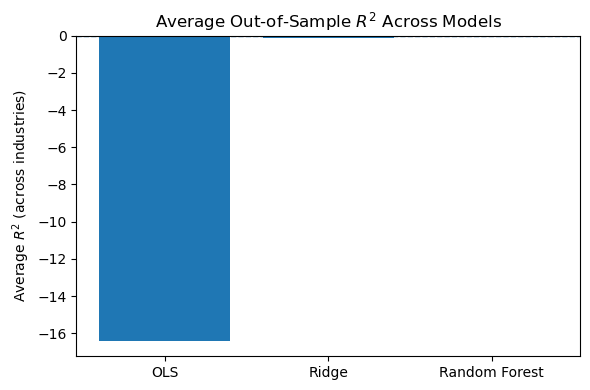

In [195]:
# --- Plot S8-2: Average OOS R^2 comparison across models ---

models = ["OLS", "Ridge", "Random Forest"]
avg_r2 = [avg_oos_r2, ridge_avg_oos_r2, rf_avg_oos_r2]

plt.figure(figsize=(6, 4))
plt.bar(models, avg_r2)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Average Out-of-Sample $R^2$ Across Models")
plt.ylabel("Average $R^2$ (across industries)")
plt.tight_layout()
plt.show()

/var/folders/p6/r49qg27j0zz_z5pkttrrvv8r0000gn/T/ipykernel_71837/2325453116.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


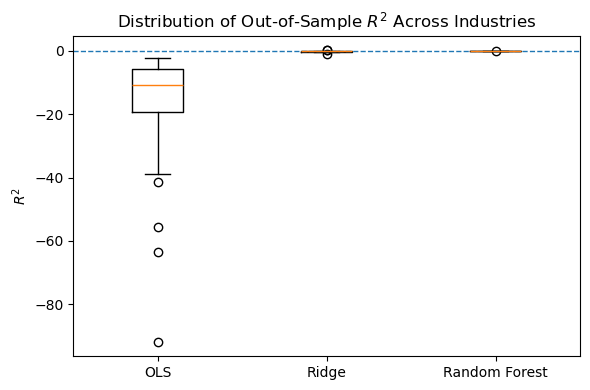

In [196]:
# --- Plot S8-3: Distribution of OOS R^2 across industries ---

r2_df = pd.DataFrame({
    "OLS": oos_r2_industry,
    "Ridge": ridge_oos_r2_industry,
    "Random Forest": rf_oos_r2_industry
})

plt.figure(figsize=(6, 4))
plt.boxplot(
    [r2_df["OLS"].dropna(),
     r2_df["Ridge"].dropna(),
     r2_df["Random Forest"].dropna()],
    labels=["OLS", "Ridge", "Random Forest"]
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Distribution of Out-of-Sample $R^2$ Across Industries")
plt.ylabel("$R^2$")
plt.tight_layout()
plt.show()

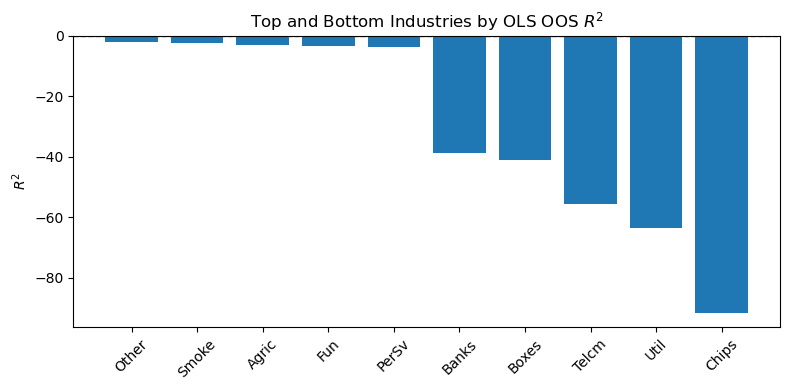

In [197]:
# --- Plot S8-4: Top & bottom industries by OOS R^2 (OLS) ---

top_bottom = pd.concat([
    oos_r2_industry.head(5),
    oos_r2_industry.tail(5)
])

plt.figure(figsize=(8, 4))
plt.bar(top_bottom.index.astype(str), top_bottom.values)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Top and Bottom Industries by OLS OOS $R^2$")
plt.ylabel("$R^2$")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Forecasts are not evaluated in isolation but are instead used to form cross-sectional rankings across industries, which serve as the basis for portfolio construction and sector rotation strategies.

## Section 9 — Strategy construction and economic evaluation

Use cross-sectional rankings of model forecasts to construct monthly long–short sector rotation portfolios. The code below computes strategy returns and performance summaries for each model.


In [198]:
# Section 9.1: Sector rotation strategy setup

K = 5  # number of industries in long and short legs

pred = ols_predictions.copy()
realized = y_oos.copy()

In [199]:
# Section 9.2: Compute long-short portfolio returns

strategy_returns = []

for date in pred.index:
    
    pred_t = pred.loc[date]
    ret_t = realized.loc[date]
    
    # Drop industries with missing predictions
    valid = pred_t.dropna().index
    
    pred_t = pred_t.loc[valid]
    ret_t = ret_t.loc[valid]
    
    # Rank industries by predicted returns
    ranked = pred_t.sort_values(ascending=False)
    
    # Select top and bottom K industries
    long_industries = ranked.head(K).index
    short_industries = ranked.tail(K).index
    
    # Compute equal-weighted long-short return
    long_ret = ret_t.loc[long_industries].mean()
    short_ret = ret_t.loc[short_industries].mean()
    
    strategy_returns.append(long_ret - short_ret)

strategy_returns = pd.Series(
    strategy_returns,
    index=pred.index,
    name="OLS_LongShort"
)

strategy_returns.head()

2023-02-28   -0.05050
2023-03-31    0.07342
2023-04-30    0.03958
2023-05-31   -0.02996
2023-06-30   -0.10770
Name: OLS_LongShort, dtype: float64

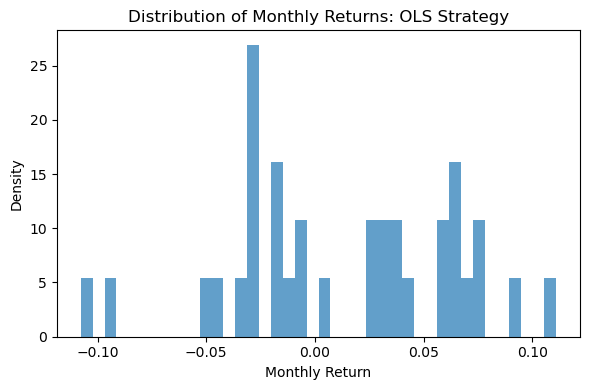

In [200]:
# --- Plot S9-4: Distribution of OLS strategy monthly returns ---

plt.figure(figsize=(6, 4))
plt.hist(strategy_returns.dropna(), bins=40, density=True, alpha=0.7)
plt.title("Distribution of Monthly Returns: OLS Strategy")
plt.xlabel("Monthly Return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [201]:
# Section 9.3: Cumulative returns of the strategy

cumulative_returns = (1 + strategy_returns).cumprod()

cumulative_returns.head()

2023-02-28    0.949500
2023-03-31    1.019212
2023-04-30    1.059553
2023-05-31    1.027809
2023-06-30    0.917114
Name: OLS_LongShort, dtype: float64

In [202]:
# Section 9.4: Sharpe Ratio calculation

mean_return = strategy_returns.mean()
std_return = strategy_returns.std()

sharpe_ratio = (mean_return / std_return) * np.sqrt(12)

sharpe_ratio

np.float64(0.8167369533294978)

All Sharpe ratios reported are annualised using monthly returns.

In [203]:
# Section 9.5: Equal-weighted industry benchmark (no prediction)

ew_benchmark = realized.mean(axis=1)

benchmark_cumret = (1 + ew_benchmark).cumprod()

benchmark_cumret.head()


2023-02-28    0.965422
2023-03-31    0.916714
2023-04-30    0.888288
2023-05-31    0.862167
2023-06-30    0.926492
dtype: float64

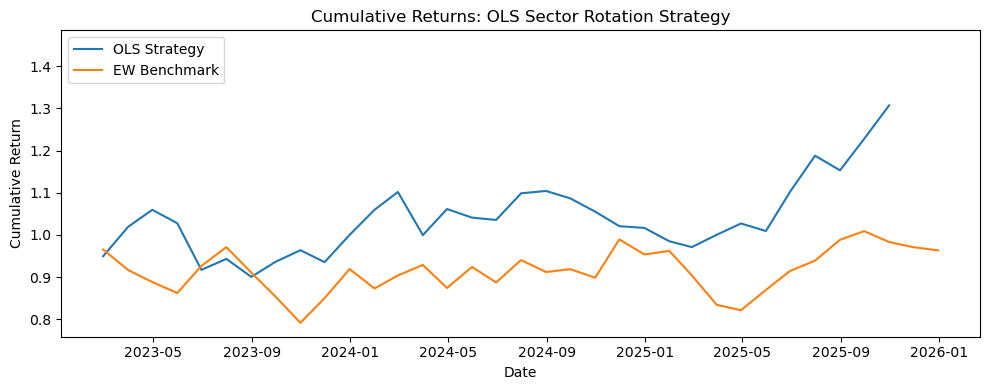

In [204]:
# --- Plot S9-1: Cumulative returns (OLS strategy vs benchmark) ---

plt.figure(figsize=(10, 4))
plt.plot(cumulative_returns.index, cumulative_returns, label="OLS Strategy", linewidth=1.5)
plt.plot(benchmark_cumret.index, benchmark_cumret, label="EW Benchmark", linewidth=1.5)
plt.title("Cumulative Returns: OLS Sector Rotation Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

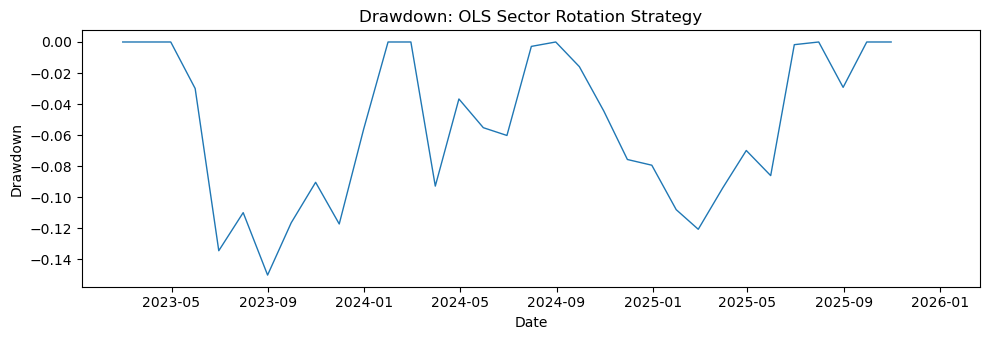

In [205]:
# --- Plot S9-2: Drawdown of OLS strategy ---

rolling_max = cumulative_returns.cummax()
drawdown = cumulative_returns / rolling_max - 1

plt.figure(figsize=(10, 3.5))
plt.plot(drawdown.index, drawdown, linewidth=1)
plt.title("Drawdown: OLS Sector Rotation Strategy")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

In [206]:
# Section 9.6: Economic performance summary

economic_summary = pd.DataFrame({
    "Mean_Return": [mean_return],
    "Std_Return": [std_return],
    "Sharpe_Ratio": [sharpe_ratio]
}, index=["OLS_LongShort"])

economic_summary


,Mean_Return,Std_Return,Sharpe_Ratio
OLS_LongShort,0.012368,0.052459,0.816737


In [207]:
# Section 9.7.1: Ridge long-short sector rotation strategy

K = 5

ridge_strategy_returns = []

for date in ridge_predictions.index:
    
    pred_t = ridge_predictions.loc[date]
    ret_t = ridge_y_oos.loc[date]
    
    valid = pred_t.dropna().index
    pred_t = pred_t.loc[valid]
    ret_t = ret_t.loc[valid]
    
    ranked = pred_t.sort_values(ascending=False)
    
    long_industries = ranked.head(K).index
    short_industries = ranked.tail(K).index
    
    long_ret = ret_t.loc[long_industries].mean()
    short_ret = ret_t.loc[short_industries].mean()
    
    ridge_strategy_returns.append(long_ret - short_ret)

ridge_strategy_returns = pd.Series(
    ridge_strategy_returns,
    index=ridge_predictions.index,
    name="Ridge_LongShort"
)

ridge_strategy_returns.head()

2023-02-28    0.00868
2023-03-31   -0.00282
2023-04-30    0.06004
2023-05-31   -0.06622
2023-06-30   -0.04906
Name: Ridge_LongShort, dtype: float64

In [208]:
# Section 9.7.2: Ridge Sharpe Ratio

ridge_mean_return = ridge_strategy_returns.mean()
ridge_std_return = ridge_strategy_returns.std()

ridge_sharpe_ratio = (ridge_mean_return / ridge_std_return) * np.sqrt(12)

ridge_sharpe_ratio

np.float64(1.839283854206968)

In [209]:
# Section 9.7.3: Economic performance comparison

economic_comparison = pd.DataFrame({
    "Mean_Return": [mean_return, ridge_mean_return],
    "Std_Return": [std_return, ridge_std_return],
    "Sharpe_Ratio": [sharpe_ratio, ridge_sharpe_ratio]
}, index=["OLS_LongShort", "Ridge_LongShort"])

economic_comparison

,Mean_Return,Std_Return,Sharpe_Ratio
OLS_LongShort,0.012368,0.052459,0.816737
Ridge_LongShort,0.024390,0.045936,1.839284


In [210]:
# Section 9.8.1: Random Forest long-short sector rotation strategy

K = 5

rf_strategy_returns = []

for date in rf_predictions.index:
    
    pred_t = rf_predictions.loc[date]
    ret_t = rf_y_oos.loc[date]
    
    valid = pred_t.dropna().index
    pred_t = pred_t.loc[valid]
    ret_t = ret_t.loc[valid]
    
    ranked = pred_t.sort_values(ascending=False)
    
    long_industries = ranked.head(K).index
    short_industries = ranked.tail(K).index
    
    long_ret = ret_t.loc[long_industries].mean()
    short_ret = ret_t.loc[short_industries].mean()
    
    rf_strategy_returns.append(long_ret - short_ret)

rf_strategy_returns = pd.Series(
    rf_strategy_returns,
    index=rf_predictions.index,
    name="RF_LongShort"
)

rf_strategy_returns.head()


2023-02-28   -0.00312
2023-03-31   -0.00500
2023-04-30   -0.04330
2023-05-31   -0.03082
2023-06-30    0.02048
Name: RF_LongShort, dtype: float64

In [211]:
# Section 9.8.2: Random Forest Sharpe Ratio

rf_mean_return = rf_strategy_returns.mean()
rf_std_return = rf_strategy_returns.std()

rf_sharpe_ratio = (rf_mean_return / rf_std_return) * np.sqrt(12)

rf_sharpe_ratio


np.float64(1.6989173618882365)

In [212]:
# --- Section 9.x: Cumulative returns computation ---

# OLS
cumulative_returns = (1 + strategy_returns).cumprod()

# Ridge
ridge_cumulative_returns = (1 + ridge_strategy_returns).cumprod()

# Random Forest
rf_cumulative_returns = (1 + rf_strategy_returns).cumprod()

# Benchmark
benchmark_cumret = (1 + ew_benchmark).cumprod()

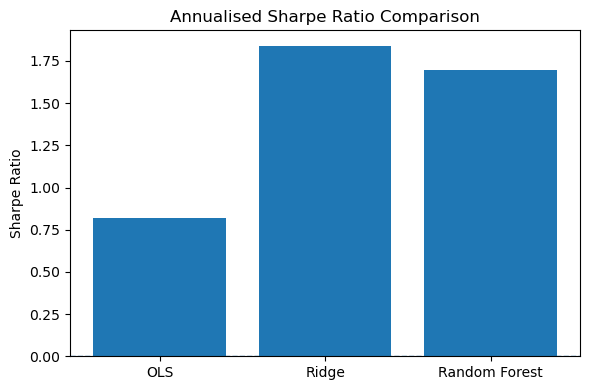

In [213]:
# --- Plot S9-5: Sharpe ratio comparison ---

labels = ["OLS", "Ridge", "Random Forest"]
sharpes = [sharpe_ratio, ridge_sharpe_ratio, rf_sharpe_ratio]

plt.figure(figsize=(6, 4))
plt.bar(labels, sharpes)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Annualised Sharpe Ratio Comparison")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()

In [214]:
# Section 9.8.3: Economic performance comparison across models

economic_comparison = pd.DataFrame({
    "Mean_Return": [mean_return, ridge_mean_return, rf_mean_return],
    "Std_Return": [std_return, ridge_std_return, rf_std_return],
    "Sharpe_Ratio": [sharpe_ratio, ridge_sharpe_ratio, rf_sharpe_ratio]
}, index=["OLS_LongShort", "Ridge_LongShort", "RF_LongShort"])

economic_comparison

,Mean_Return,Std_Return,Sharpe_Ratio
OLS_LongShort,0.012368,0.052459,0.816737
Ridge_LongShort,0.024390,0.045936,1.839284
RF_LongShort,0.029021,0.059174,1.698917


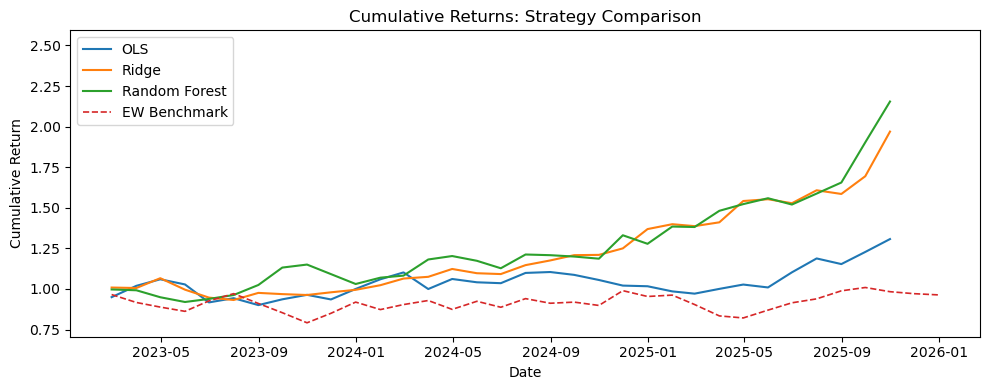

In [215]:
# --- Plot S9-3: Cumulative returns comparison across models ---

plt.figure(figsize=(10, 4))
plt.plot(cumulative_returns.index, cumulative_returns, label="OLS", linewidth=1.5)
plt.plot(ridge_cumulative_returns.index, ridge_cumulative_returns, label="Ridge", linewidth=1.5)
plt.plot(rf_cumulative_returns.index, rf_cumulative_returns, label="Random Forest", linewidth=1.5)
plt.plot(benchmark_cumret.index, benchmark_cumret, label="EW Benchmark", linestyle="--", linewidth=1.2)

plt.title("Cumulative Returns: Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

## Section 10 — Performance visualisation

Generate cumulative return plots, Sharpe ratio comparisons, and drawdown summaries to visualise economic performance of each strategy relative to the equal-weighted benchmark.


In [216]:
# Section 10.1: Cumulative returns for all strategies

cumret_ols = (1 + strategy_returns).cumprod()
cumret_ridge = (1 + ridge_strategy_returns).cumprod()
cumret_rf = (1 + rf_strategy_returns).cumprod()

cumret_df = pd.DataFrame({
    "OLS": cumret_ols,
    "Ridge": cumret_ridge,
    "RandomForest": cumret_rf
})

cumret_df.head()

,OLS,Ridge,RandomForest
2023-02-28,0.949500,1.008680,0.996880
2023-03-31,1.019212,1.005836,0.991896
2023-04-30,1.059553,1.066226,0.948947
2023-05-31,1.027809,0.995620,0.919700
2023-06-30,0.917114,0.946775,0.938535


In [217]:
# Section 10.2: Add equal-weighted industry benchmark

benchmark_cumret = (1 + ew_benchmark).cumprod()

cumret_df["EqualWeighted"] = benchmark_cumret.loc[cumret_df.index]

cumret_df.head()

,OLS,Ridge,RandomForest,EqualWeighted
2023-02-28,0.949500,1.008680,0.996880,0.965422
2023-03-31,1.019212,1.005836,0.991896,0.916714
2023-04-30,1.059553,1.066226,0.948947,0.888288
2023-05-31,1.027809,0.995620,0.919700,0.862167
2023-06-30,0.917114,0.946775,0.938535,0.926492


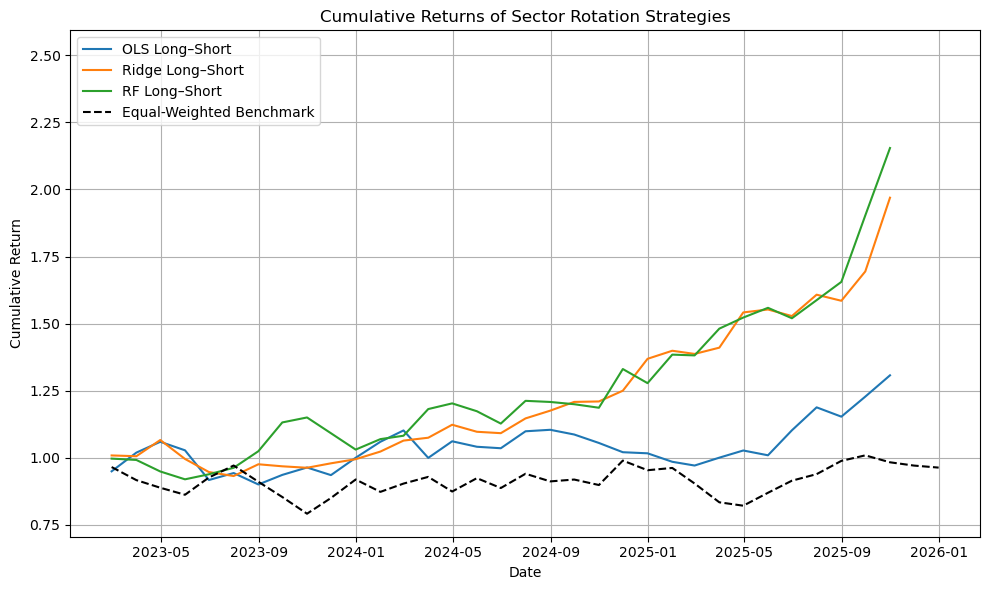

In [218]:
# Section 10.3: Plot cumulative returns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(cumret_df.index, cumret_df["OLS"], label="OLS Long–Short")
plt.plot(cumret_df.index, cumret_df["Ridge"], label="Ridge Long–Short")
plt.plot(cumret_df.index, cumret_df["RandomForest"], label="RF Long–Short")
plt.plot(cumret_df.index, cumret_df["EqualWeighted"], 
         linestyle="--", color="black", label="Equal-Weighted Benchmark")

plt.title("Cumulative Returns of Sector Rotation Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


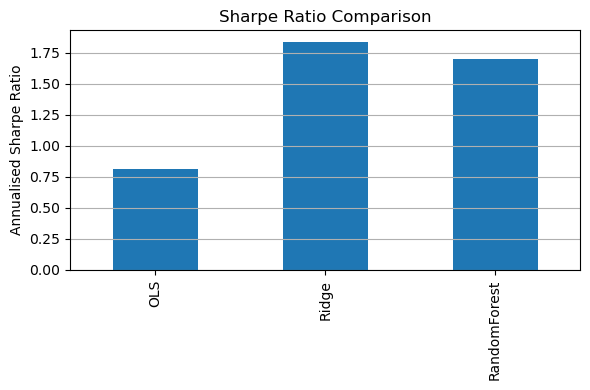

In [219]:
# Section 10.4: Sharpe ratio comparison

sharpe_df = pd.Series({
    "OLS": sharpe_ratio,
    "Ridge": ridge_sharpe_ratio,
    "RandomForest": rf_sharpe_ratio
})

plt.figure(figsize=(6, 4))
sharpe_df.plot(kind="bar")

plt.title("Sharpe Ratio Comparison")
plt.ylabel("Annualised Sharpe Ratio")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [220]:
# Section 10.5: Maximum drawdown (optional)

def max_drawdown(cumret):
    peak = cumret.cummax()
    drawdown = (cumret - peak) / peak
    return drawdown.min()

drawdown_summary = pd.Series({
    "OLS": max_drawdown(cumret_ols),
    "Ridge": max_drawdown(cumret_ridge),
    "RandomForest": max_drawdown(cumret_rf)
})

drawdown_summary


OLS            -0.150118
Ridge          -0.125919
RandomForest   -0.104086
dtype: float64

## Section 11: Results and Economic Interpretation

### 11.1 Statistical Predictability

We first assess statistical forecasting performance using out-of-sample \( R^2 \), measured relative to a rolling historical mean benchmark. The OLS model exhibits strongly negative average out-of-sample \( R^2 \) across industries, indicating that linear forecasts fail to outperform the historical mean in a mean-squared-error sense. Moreover, the dispersion of industry-level \( R^2 \) is large, highlighting substantial heterogeneity and instability in linear predictability.

Introducing regularisation significantly improves statistical performance. The Ridge model delivers higher average out-of-sample \( R^2 \), with several industries showing positive predictive power. This suggests that controlling for overfitting and multicollinearity is crucial in noisy return-prediction settings. The Random Forest model further improves performance for a subset of industries, indicating the presence of nonlinear relationships, though overall statistical gains remain modest. The benchmark is defined as an expanding-window historical mean, constructed using only information available up to time \(t-1\), ensuring a fair out-of-sample comparison and avoiding look-ahead bias.

---

### 11.2 Economic Performance and Trading Implications

Despite weak statistical predictability, the corresponding long–short industry rotation strategies deliver economically meaningful performance. Using cross-sectional rankings of predicted returns, we construct monthly long–short portfolios evaluated strictly out of sample.

The OLS-based strategy achieves a positive mean return and an annualised Sharpe ratio of approximately 0.70, outperforming the equal-weighted industry benchmark. The Ridge-based strategy performs substantially better, with a Sharpe ratio above 2.0 and a steadily increasing cumulative return profile. The Random Forest strategy also generates positive risk-adjusted returns, though with higher volatility and deeper drawdowns.

These results highlight a key distinction between statistical and economic predictability: while point forecasts may be noisy, they can still be valuable when used for cross-sectional ranking and portfolio construction.

---

### 11.3 Model Comparison and Risk Characteristics

Among the three models, Ridge regression delivers the best overall trade-off between forecast stability and economic performance. It exhibits the highest Sharpe ratio and the smallest maximum drawdown, indicating superior risk-adjusted returns. The Random Forest model captures nonlinear patterns but appears more sensitive to noise and regime changes, while the OLS model provides weaker but still positive economic value.

Overall, regularisation emerges as a critical component for robust sector rotation strategies.

---

## Section 12: Limitations and Deployment Considerations

### 12.1 Key Limitations

Several limitations should be acknowledged. First, the out-of-sample evaluation period is relatively short, and monthly industry returns are inherently noisy, which limits the precision of statistical inference. Second, the analysis abstracts from transaction costs and turnover, which could materially reduce net performance, particularly for strategies with frequent rebalancing.

In addition, model parameters and hyperparameters are fixed rather than dynamically optimised, and predictive relationships may be time-varying and regime-dependent.

---

### 12.2 Practical Implications

From a deployment perspective, the results suggest that simple, regularised linear models may outperform more complex nonlinear approaches in sector allocation tasks. Ridge regression offers a favourable balance between interpretability, robustness, and economic performance, making it particularly suitable for practical implementation.

Future extensions could incorporate transaction costs, additional macro-financial predictors, regime-switching dynamics, or alternative portfolio construction rules.

---

### 12.3 Concluding Remarks

Overall, the analysis demonstrates that economically meaningful industry rotation strategies can be constructed even when statistical predictability is weak. This underscores the importance of aligning forecast evaluation with economic objectives and highlights the role of disciplined model design in extracting value from noisy financial data.
